In [2]:
import logging, warnings
import numpy as np, pandas as pd
from pathlib import Path
from scipy.stats import spearmanr, ConstantInputWarning
from tqdm import tqdm
from umap import UMAP
from dtaidistance import dtw
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import pathlib
import importlib

from src.utils import iter_dataset_dirs, load_json
from src.plot_style import apply_plot_style
from src.visualization import plot_mts_corr_density, plot_spi_space_individual

apply_plot_style()
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
warnings.simplefilter("ignore", ConstantInputWarning)


In [9]:
def generate_ar1(T: int, a: float, noise_std: float, seed=None):
    rng = np.random.default_rng(seed)
    X = np.zeros(T)
    for t in range(1, T):
        X[t] = a * X[t-1] + rng.normal(0, noise_std)
    return X

def warp_path(T: int, p: float = 0.5, step: int = 1, seed=None):
    """Generate a random monotone warping path from (0,0) to (T-1, T-1)."""
    rng = np.random.default_rng(seed)
    x, y = 0, 0
    path = [(x, y)]
    while x < T - 1 or y < T - 1:
        if x >= T - 1:
            y = min(y + step, T - 1)
        elif y >= T - 1:
            x = min(x + step, T - 1)
        else:
            if rng.random() < p:
                x = min(x + step, T - 1)
            else:
                y = min(y + step, T - 1)
        path.append((x, y))
    return np.array(path, dtype=int)

def path_to_mapping(path: np.ndarray, T: int):
    n = np.zeros(T, dtype=int)
    s = np.zeros(T, dtype=float)
    for x, y in path:
        n[y] += 1
        s[y] += x
    m = np.zeros(T, dtype=int)
    for y in range(T):
        m[y] = int(round(s[y] / n[y])) if n[y] > 0 else 0
    m = np.clip(m, 0, T - 1)
    m = np.maximum.accumulate(m)
    return m

def warp_series(X_orig: np.ndarray, mapping: np.ndarray):
    return X_orig[mapping].copy()

/var/folders/nq/8y70t4y10yb6nq4v5m7p_j340000gp/T/ipykernel_16874/3904113039.py:22: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  ax.plot(path[:, 0], path[:, 1], 'b-', lw=1.5, label="Warp path", color="purple")


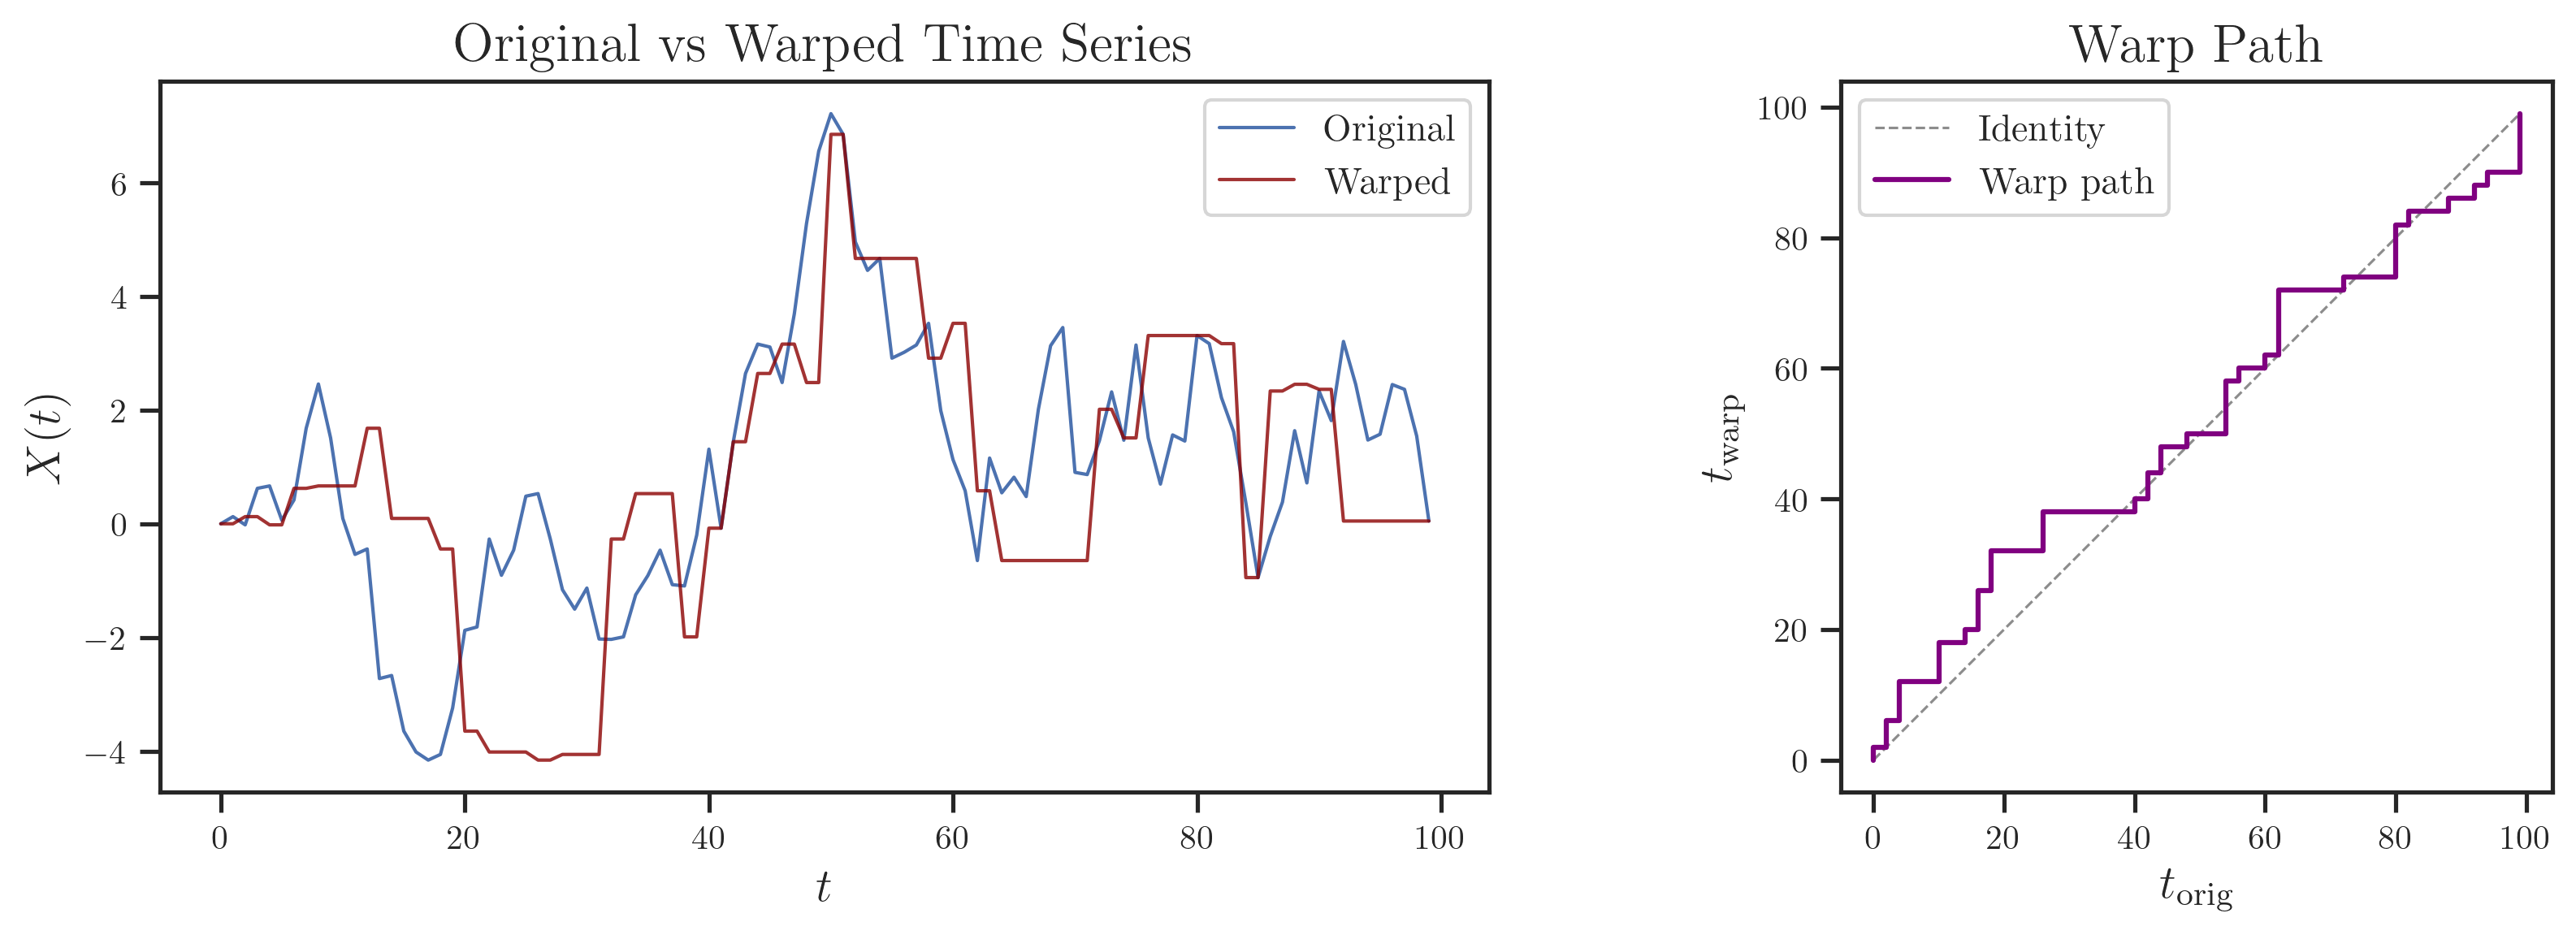

In [13]:
if __name__ == "__main__":
    T = 100
    X = generate_ar1(T=T, a=0.9, noise_std=1.0, seed=0)
    path = warp_path(T=T, p=0.5, step=2, seed=42)
    mapping = path_to_mapping(path, T=T)
    X_warp = warp_series(X, mapping)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=300)

    # Left: Original vs Warped signals
    ax = axes[0]
    ax.plot(X, label="Original", lw=1.0)
    ax.plot(X_warp, label="Warped", lw=1.0, alpha=0.8, color="darkred")
    ax.set_xlabel(r"$t$")
    ax.set_ylabel(r"$X(t)$")
    ax.set_title("Original vs Warped Time Series")
    ax.legend()

    # Right: Warp path in (t_orig, t_warp) space
    ax = axes[1]
    ax.plot([0, T-1], [0, T-1], 'k--', lw=0.75, alpha=0.5, label="Identity")
    ax.plot(path[:, 0], path[:, 1], 'b-', lw=1.5, label="Warp path", color="purple")
    ax.set_xlabel(r"$t_{\mathrm{orig}}$")
    ax.set_ylabel(r"$t_{\mathrm{warp}}$")
    ax.set_title("Warp Path")
    ax.set_aspect("equal")
    ax.legend()

    fig.tight_layout()
    plt.show()

In [14]:
print("Computed distances:")
euclidean = np.linalg.norm(X - X_warp)  # pdist_euclidean 
print(f"pdist_euclidean: {euclidean}")
dtw_dist = dtw.distance(X, X_warp, use_c=True)
print(f"dtw: {dtw_dist}")
dtw_sakoe_chiba = dtw.distance(X, X_warp, window=50, use_c=True)
print(f"dtw_sakoe_chiba: {dtw_sakoe_chiba}")

2026-02-11 08:55:30,492 ERROR The compiled dtaidistance C library is not available.
See the documentation for alternative installation options.


Computed distances:
pdist_euclidean: 20.765097615870538


CythonException: The compiled dtaidistance C library is not available.
See the documentation for alternative installation options.